### Enable Code Execution with images

part.executable_code.code import PIL.Image
import PIL.ImageDraw

# Load the image to get dimensions
img = PIL.Image.open('input_file_0.jpeg')
width, height = img.size

# Expression pedals are located roughly in the center, above the pedals
# Let's define the region for expression pedals
# Normalized coordinates roughly [450, 460, 620, 620]
expression_pedals_box = [463, 467, 611, 612] # [ymin, xmin, ymax, xmax]

# Convert normalized to pixel coordinates
def norm_to_pixel(norm_box, w, h):
    ymin, xmin, ymax, xmax = norm_box
    return [ymin * h / 1000, xmin * w / 1000, ymax * h / 1000, xmax * w / 1000]

pixel_box = norm_to_pixel(expression_pedals_box, width, height)
expression_pedals_crop = img.crop((pixel_box[1], pixel_box[0], pixel_box[3], pixel_box[2]))
expression_pedals_crop.save('expression_pedals.png')

# Displaying objects for internal reference
# [{box_2d: [463, 467, 611, 612], label: 'expression pedals'}]

--------------------------------


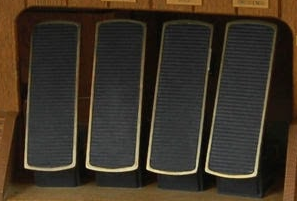

part.text  Based on the zoomed-in image, there are 4 expression pedals.
--------------------------------
part.text Based on the zoomed-in image, there are 4 expression pedals located in the center of the console above the pedalboard.
--------------------------------


In [ ]:
from google import genai
from google.genai import types
import requests
from PIL import Image
import io
from dotenv import load_dotenv
import os
load_dotenv()

image_path = "https://goo.gle/instrument-img"
image_bytes = requests.get(image_path).content
image = types.Part.from_bytes(data=image_bytes, mime_type="image/jpeg")

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[
        image,
        "Zoom into the expression pedals and tell me how many pedals are there?"
    ],
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    ),
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print('part.text \n',part.text)
        print('--------------------------------')
    if part.executable_code is not None:
        print('part.executable_code.code \n',part.executable_code.code)
        print('--------------------------------')
    if part.code_execution_result is not None:
        print('part.code_execution_result.output \n',part.code_execution_result.output)
        print('--------------------------------')
    if part.as_image() is not None:
        display(Image.open(io.BytesIO(part.as_image().image_bytes)))

### Use code execution in chat

In [ ]:
from google import genai
from google.genai import types

client = genai.Client()

chat = client.chats.create(
    model="gemini-3-flash-preview",
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    ),
)

response = chat.send_message("I have a math question for you.")
print(response.text)

response = chat.send_message(
    "What is the sum of the first 50 prime numbers? "
    "Generate and run code for the calculation, and make sure you get all 50."
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    if part.executable_code is not None:
        print(part.executable_code.code)
    if part.code_execution_result is not None:
        print(part.code_execution_result.output)